In [1]:
# TensorFlow 2.0 부터 TensorFlow 2.15 버전까지는 텐서플로와 동일한 버전의 Keras 2가 설치되고 2.16 이후의 텐서플로 설치 시에는 Keras 3이 설치
# Keras 버전에 따라 패키지 임포트 방법이 다름

# 필요한 경우 packaging 모듈 설치
# !pip install packaging

import tensorflow as tf
from packaging import version

print(tf.__version__)

2.20.0


In [2]:
from tensorflow import keras

print(keras.__version__)

3.13.2


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras import optimizers

# TensorFlow 버전 정보 가져오기
tf_version = version.parse(tf.__version__)

# 필요한 라이브러리를 불러옵니다.
# TensorFlow 2.15 이하인 경우
if tf_version <= version.parse("2.15.0"):
  from keras.models import Sequential, load_model
  from keras.layers import Dense
  print(f"TensorFlow 버전: {tf.__version__} (2.15 이하) -> tensorflow.keras 임포트")
# TensorFlow 2.15 초과인 경우 (Keras 3 사용)
else:
  from keras.layers import Dense
  from keras.models import Sequential, load_model
  print(f"TensorFlow 버전: {tf.__version__} (2.15 초과) -> Keras 3 임포트")

# 실행할 때마다 같은 결과를 출력하기 위해 설정하는 부분입니다.
np.random.seed(3)
tf.random.set_seed(3)

TensorFlow 버전: 2.20.0 (2.15 초과) -> Keras 3 임포트


In [4]:
# data set
x_data = np.array([2, 4, 6, 8, 10, 12, 14])
y_data = np.array([0, 0, 0, 1, 1, 1, 1])

In [5]:
# model: linear regression input dense with dim =1
model = Sequential()
model.add(Dense(1, input_dim = 1, activation='sigmoid'))

# print model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# model compile:  SGD learning_rate of 0.01
sgd = optimizers.SGD(learning_rate = 0.001)
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [7]:
# model fit
#history = model.fit(x_data, y_data, epochs=20, batch_size=1, shuffle=False, verbose=1)
history = model.fit(x_data, y_data, epochs=300, batch_size=1, verbose=1)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5714 - loss: 0.9799  
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5714 - loss: 0.9629 
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 0.9461 
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 0.9294 
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.9131  
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 0.8969 
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.8810 
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.8653 
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 0.8500 
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 0.8349 
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.8200 
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - l

In [8]:
print(model.layers[0].get_weights())

[array([[0.17462963]], dtype=float32), array([-0.37053826], dtype=float32)]


In [9]:
# prediction
print (model.predict(np.array([7])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.7009591]]


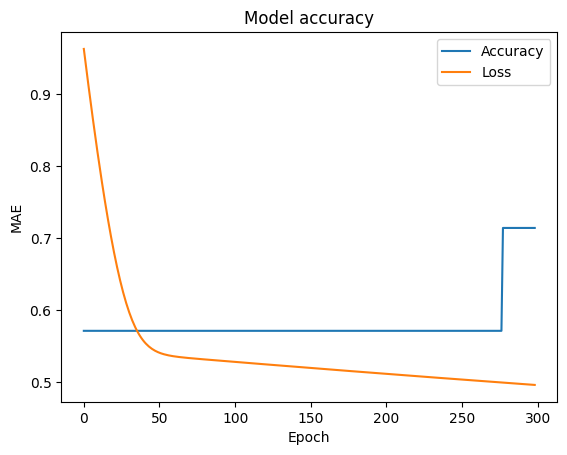

In [10]:
# 학습 정확성 값과 검증 정확성 값을 플롯팅 합니다.
plt.plot(history.history['accuracy'][1:])
plt.plot(history.history['loss'][1:])
plt.title('Model accuracy')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Loss'], loc='upper right')
plt.savefig('tran_result.png')